In [90]:
import os
import re
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from pydantic import BaseModel
from sqlalchemy.testing.suite.test_reflection import metadata
from streamlit import title

load_dotenv()

True

In [91]:
import os
os.environ['LANGCHAIN_PROJECT'] = "crag"

In [92]:

docs = (
    PyPDFLoader(r"C:\Users\amito\PycharmProjects\langraph_scripts\CRAG\2.Designing Machine Learning Systems An Iterative Process for Production-Ready (Chip Huyen).pdf").load() +
    PyPDFLoader(r"C:\Users\amito\PycharmProjects\langraph_scripts\CRAG\Storytelling-with-Data_-A-Data-Visualization-Guide-for-Busine....pdf").load()
)

In [93]:
len(docs)

673

In [94]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [95]:
len(chunks)

1836

In [96]:
# 3) Index (fresh collection each run)
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [97]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


In [98]:
# 4) LLM + prompt
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [99]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [100]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

    good_docs : List[Document]
    web_docs : List[Document]
    verdict: str
    reason : str

    strips : List[str]
    kept_strips : List[str]
    refined_context : str

    web_query: str


In [101]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [102]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) :

    q = state["question"]

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [103]:
def clean_scraped_text(text: str) -> str:
    lines = text.split("\n")
    clean_lines = []
    for line in lines:
        line = line.strip()
        if not line:
            continue
        # Drop lines that look like markdown headers or headline-list bylines
        # (e.g. "AI ### Nvidia buys Hugging Face + Ram Iyer")
        if line.count("#") >= 2 or line.count("+") >= 2:
            continue
        clean_lines.append(line)
    return " ".join(clean_lines)


In [129]:
# Knowledge Refinement

def decompose_to_sentences(text: str) -> List[str]:
    text = clean_scraped_text(text)          # <-- add this line
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

class KeepOrDrop(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

def refine(state: State) :

     q = state['question']

     if state['verdict'] == 'CORRECT':
         docs_to_use = state["good_docs"]

     elif state['verdict'] == 'INCORRECT':
         docs_to_use = state["web_docs"]
     else:
         docs_to_use = state["good_docs"] + state["web_docs"]

     context = "\n\n".join(d.page_content for d in docs_to_use).strip()

     strips = decompose_to_sentences(context)

     kept : List[str] = []

     for s in strips:
         if filter_chain.invoke({"question":q , "sentence": s}).keep:
             kept.append(s)


     refined_context = "\n\n".join(kept).strip()

     return {
         "strips": strips,
         "kept_strips": kept,
         "refined_context": refined_context,
     }

In [130]:
class QueryRewrite(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(QueryRewrite)

def rewrite_query(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

In [131]:
# -----------------------------
# Web search (Iteration 4)
# Assumption: web search does not fail (no fail node in this branch)


from langchain_tavily import TavilySearch
# -----------------------------
tavily = TavilySearch(max_results=5, search_depth="advanced", include_answer=True)

def web_search(state: State) -> State:

    q = state["web_query"] or state['question']  # no query rewrite
    response = tavily.invoke({"query": q})  # no knowledge selection
    results = response.get("results", [])

    web_docs = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")


        web_docs.append(Document(page_content=content, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [132]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State):
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [134]:

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

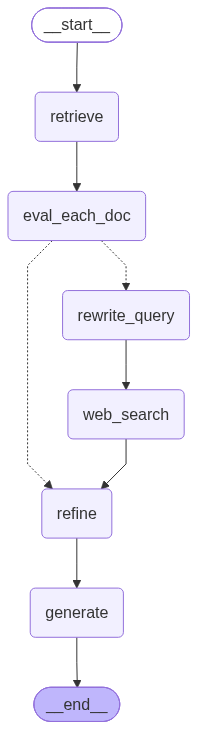

In [135]:
# -----------------------------
# Graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("web_search", web_search)
g.add_node("rewrite_query", rewrite_query)
g.add_node("refine", refine)          # uses verdict to pick good_docs vs web_docs
g.add_node("generate", generate)

# flow
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

# route after evaluation
g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",              # CORRECT -> refine (good_docs)
        "rewrite_query": "rewrite_query",  # INCORRECT -> query_rewrite -> web_search
    },
)

# ✅ key change: web_search now goes through refine
g.add_edge("rewrite_query","web_search")
g.add_edge("web_search", "refine")    # INCORRECT -> refine (web_docs)
g.add_edge("refine", "generate")      # CORRECT/INCORRECT -> generate

g.add_edge("generate", END)


app = g.compile()
app

In [144]:

res = app.invoke(
    {
        "question": "What is Data Visualtion?, what do we mean by llmp-ops",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3. Mixed relevance signals.

OUTPUT:
 Data visualization is the process of visually navigating and analyzing data to tell stories and support data-driven decision making. It is a crucial step in the analytical process, helping to make complex datasets more understandable.

LLMOps, or Large Language Model Operations, refers to the practices, techniques, and tools used for the operational management of large language models in production environments. This includes aspects like role-based access control, dataset search and exploration, data provenance tracking, and data visualization through dashboards.


In [145]:
print(len(res["kept_strips"]))

4


In [146]:
print(len(res["strips"]))

54


In [143]:
print(res['web_query'])

Mlops vs Llmops comparison


In [147]:

print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

challenge is that data visualization is a single step in the analytical 
process. Those hired into analytical roles typically have quantita -
tive backgrounds that suit them well for the other steps (finding the 
data, pulling it together, analyzing it, building models), but not nec-
essarily any formal training in design to help them when it comes to 
the communication of the analysis—which, by the way, is typically 
the only part of the analytical process that your audience ever sees. 
And increasingly, in our ever more data‐driven world, those without 
technical backgrounds are being asked to put on analytical hats and 
communicate using data.
The feelings of discomfort you may experience in this space aren’t 
surprising, given that being able to communicate effectively with 
data isn’t something that has been traditionally taught. Those who
****************************************************************************************************
8 introduction
Being able to tell stories 